# 01 · Pipeline de velocidades

Copia fiel del pipeline de `main.ipynb` (carga → preprocesado → tracking → cálculo de velocidades → matriz/campo de velocidades → animación).

Diferencias respecto a `main.ipynb`:
- Las rutas de los `.tif` apuntan a `../` (este notebook vive en `notebooks/`).
- Las **velocidades se guardan en disco** (`../outputs/t_velocities.pkl`) **antes** del filtro de banda, para que el notebook de análisis tenga la distribución completa.
- La **matriz de campo** (`Px`, `Py`) y la **animación** se guardan en `../outputs/`.


# Notebook Pruebas

In [59]:
from matplotlib import pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
import trackpy as tp
from skimage import io
import pandas as pd
import pims
import numpy as np
from IPython.display import HTML # For showing the video in Jupyter Notebook


## Archivos

In [60]:
# .tif
PATH_2FPS = "../2fps.tif"
PATH_10FPS = "../10fps.tif"
PATH_40FPS = "../40fps.tif"
PATH_80FPS = "../80fps_black.tif"

STARTING_FRAME = 100
CUT_TOP = 0
CUT_BOTTOM = 30

frames = pims.open(PATH_80FPS)

In [61]:
frames.shape

(7484, 1008, 440)

## Preprocesado

n_frames: 7384 | frame: (1008, 440) | dtype: uint8


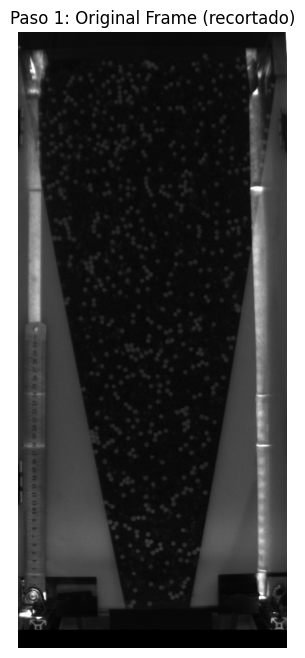

In [62]:
# pims es perezoso: leemos frame a frame para no cargar el stack entero en RAM.
frames = frames[STARTING_FRAME:]

n_frames = len(frames)
H, W = np.asarray(frames[0]).shape
print("n_frames:", n_frames, "| frame:", (H, W), "| dtype:", np.asarray(frames[0]).dtype)


def load_frame(i):
    """Frame i como float32 con los recortes (CUT_TOP/CUT_BOTTOM) aplicados."""
    f = np.asarray(frames[i], dtype=np.float32)
    if CUT_TOP:
        f[:CUT_TOP, :] = 0
    if CUT_BOTTOM:
        f[-CUT_BOTTOM:, :] = 0
    return f


plt.figure(figsize=(6, 8))
plt.imshow(load_frame(1), cmap="gray")
plt.title("Paso 1: Original Frame (recortado)")
plt.axis("off")
plt.show()

Ahora el **fondo es oscuro** (silo vacío = poca luz), así que el estado de referencia de cada píxel es su **mínimo temporal** (`np.min`), no el máximo. Lo calculamos frame a frame con `np.minimum` para no cargar el stack completo en memoria.

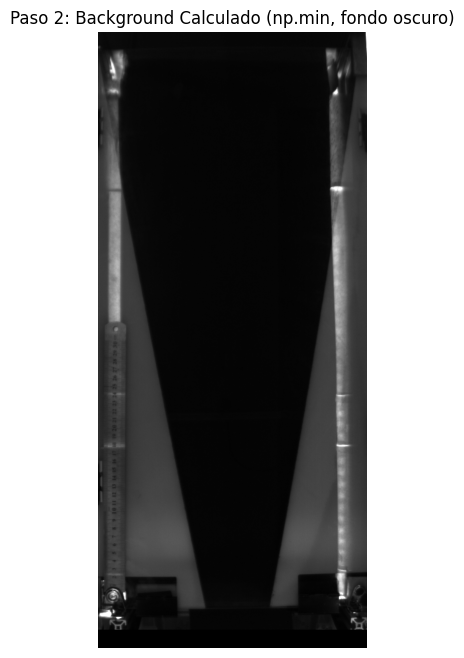

In [63]:
# Background = mínimo temporal de cada píxel (silo vacío = oscuro). Streaming con np.minimum.
background = load_frame(0)
for i in range(1, n_frames):
    np.minimum(background, load_frame(i), out=background)

plt.figure(figsize=(6, 8))
plt.imshow(background, cmap="gray")
plt.title("Paso 2: Background Calculado (np.min, fondo oscuro)")
plt.axis("off")
plt.show()

### Límites de contraste

Con el fondo ya calculado, fijamos el rango que estiraremos sobre `frame − background`:
- **`v_min`** = nivel del **fondo** → todo lo que caiga por debajo se irá a **negro** (esto es lo que sube el contraste real).
- **`v_max`** = brillo típico de las **trazadoras** (percentil 99.9).

Estimamos ambos recorriendo ~1000 frames, pero con un percentil *por frame* + mediana, así usamos mucha muestra sin cargar arrays enormes.

In [64]:
# Límites de contraste sobre (frame - background): v_min = fondo (p50), v_max = trazadoras (p99.9).
# Muestreamos ~1000 frames con percentil por-frame + mediana (1 frame en RAM).
stride = max(1, n_frames // 1000)
p_lo, p_hi = [], []
for i in range(0, n_frames, stride):
    signal = load_frame(i) - background
    p_lo.append(np.percentile(signal, 50))
    p_hi.append(np.percentile(signal, 99.9))

v_min = float(np.median(p_lo))
v_max = float(np.median(p_hi))
print("frames muestreados:", len(p_hi), "| v_min:", v_min, "| v_max:", v_max)

frames muestreados: 1055 | v_min: 5.0 | v_max: 38.0


Como ahora las trazadoras son **claras sobre fondo oscuro**, restamos el fondo al frame (`frame − background`) para realzarlas. Al ser `background` el mínimo temporal, esta resta **nunca es negativa**: el fondo queda cerca de 0 y las trazadoras en valores positivos.

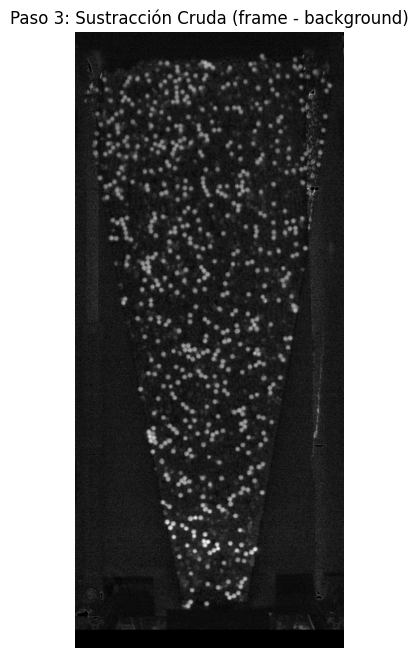

In [65]:
# Ejemplo de sustracción cruda de UN frame (fondo oscuro -> trazadora positiva)
raw_example = load_frame(1) - background
plt.figure(figsize=(6, 8))
plt.imshow(raw_example, cmap="gray")
plt.title("Paso 3: Sustracción Cruda (frame - background)")
plt.axis("off")
plt.show()
del raw_example

Para maximizar la precisión sub-píxel de Trackpy, estiramos el rango dinámico de la imagen para que las trazadoras sean lo más brillantes posible sin llegar a saturarse y perder su forma gaussiana.

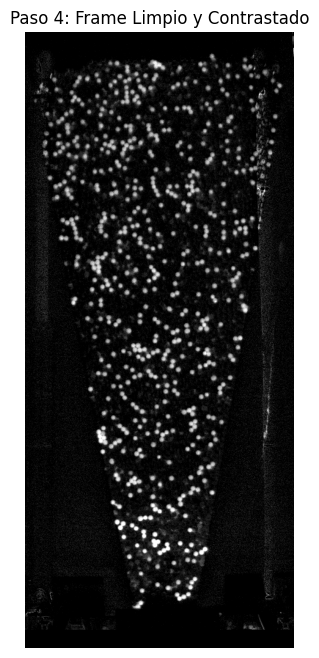

In [66]:
# Sustracción + estiramiento a uint8, frame a frame (sólo la salida uint8 vive en RAM).
# La resta con min-background ya borra los reflejos persistentes -> no hace falta máscara aparte.
scale = 240.0 / (v_max - v_min)
frames_masked = np.empty((n_frames, H, W), dtype=np.uint8)
buf = np.empty((H, W), dtype=np.float32)

for i in range(n_frames):
    np.subtract(load_frame(i), background, out=buf)
    buf -= v_min
    buf *= scale
    np.clip(buf, 0, 255, out=buf)
    frames_masked[i] = buf

del background

plt.figure(figsize=(6, 8))
plt.imshow(frames_masked[100], cmap="gray")
plt.title("Paso 4: Frame Limpio y Contrastado")
plt.axis("off")
plt.show()

## Tracking / trackpy

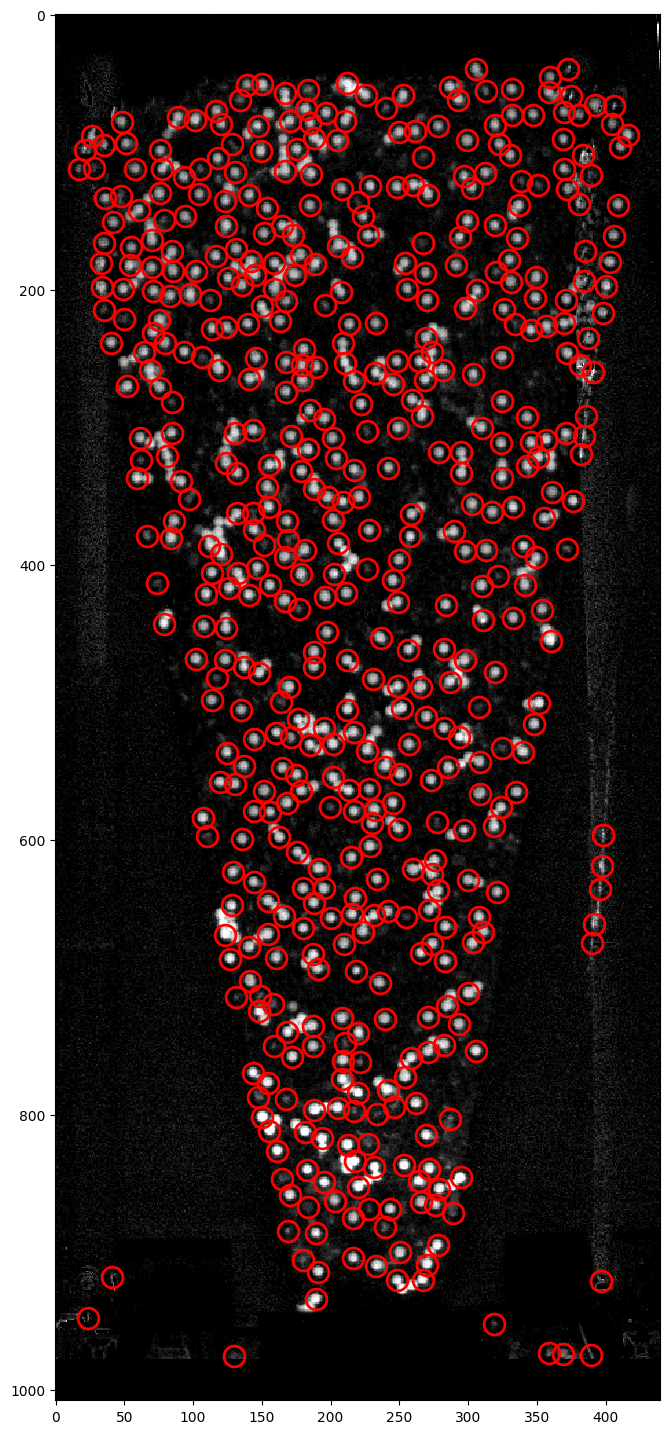

<Axes: >

In [67]:
# Detección alineada con Guido (§4.3.1, TrackMate LoG): diámetro ~9 px.
# D=9, minmass=450 -> ~531 bolitas, ruido de baja masa bien separado.
DIAMETER = 9
MINMASS = 450

test_features = tp.locate(frames_masked[100], DIAMETER, minmass=MINMASS)

plt.figure(figsize=(18, 18))
tp.annotate(test_features, frames_masked[100])

In [68]:
tp.quiet()

features = tp.batch(frames_masked, diameter=DIAMETER, minmass=MINMASS)
print(len(features), "features encontrados en toda la secuencia")

# Enlazado alineado con Guido (§4.3.1): search_range=9 px (~1 diámetro; subirlo confunde
# trazas vecinas), memory=4 (cierra huecos de hasta 4 cuadros). Predictor por velocidad.
predictor = tp.predict.NearestVelocityPredict()
t_unfiltered = predictor.link_df(features, search_range=9, memory=4)
print("distinct particles (con stubs y bolitas casi estáticas): ",
      t_unfiltered.particle.nunique())

2621480 features encontrados en toda la secuencia
distinct particles (con stubs y bolitas casi estáticas):  36179


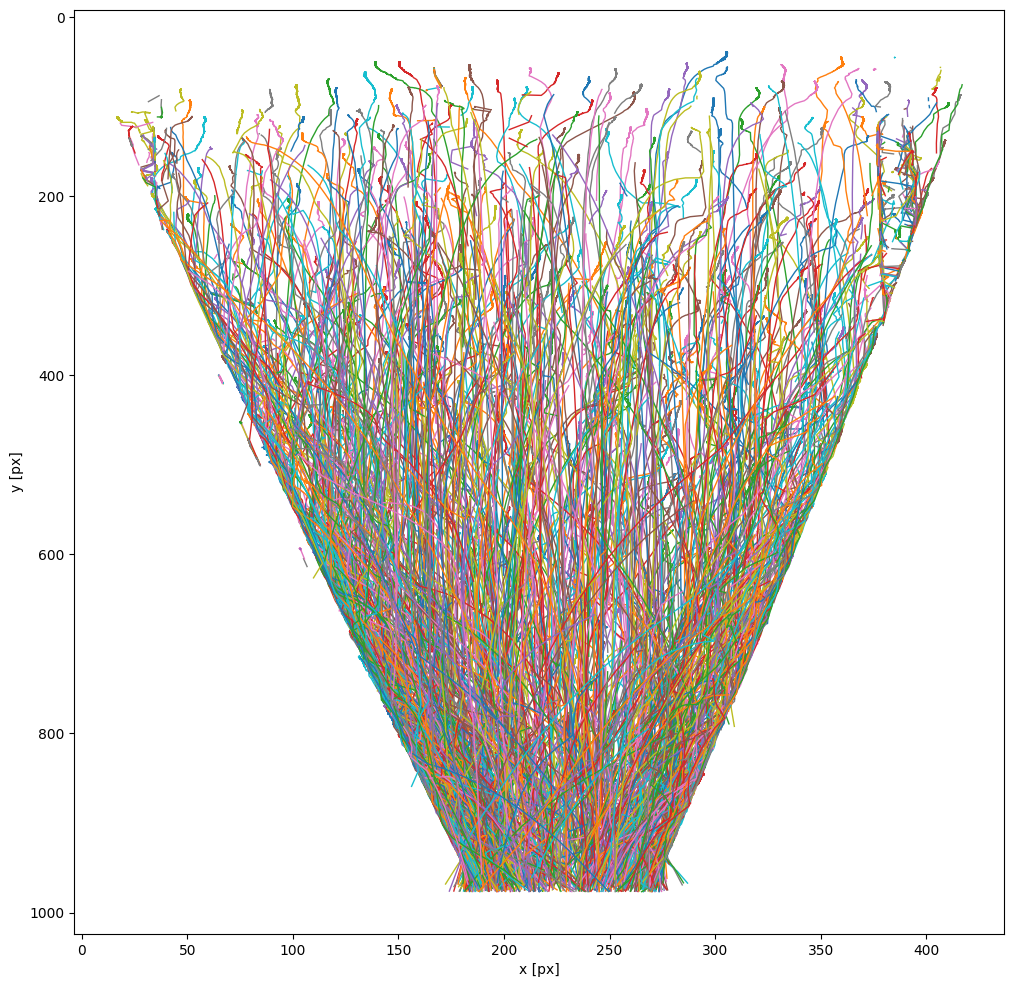

distinct particles with trajectory tracked:  2069


In [70]:
t = tp.filter_stubs(t_unfiltered, 10)   # Guido §4.3.1.3: trazas de >=10 cuadros
t = t.reset_index(drop=True)            # filter_stubs deja 'frame' como índice y columna

# Exigimos caída neta (y crece hacia abajo): descarta bolitas que sólo vagan sin desplazarse.
MIN_FALL = 20  # px
_ends = t.sort_values(['particle', 'frame']).groupby('particle')['y'].agg(['first', 'last'])
_falling = _ends.index[(_ends['last'] - _ends['first']) > MIN_FALL]
t = t[t.particle.isin(_falling)]

plt.figure(figsize=(12, 12))
tp.plot_traj(t)
print("distinct particles with trajectory tracked: ", t.particle.nunique())

## Campo de velocidades 

### Calculo 

In [71]:
t = t.reset_index(drop=True).copy()

Ordenamos por particula y por tiempo (frame) para garantizar la diferencia entre particulas.  

In [72]:
t.sort_values(['particle', 'frame'], inplace=True)


Luego utilizamos el Filtro de `Savtizky-Golay` en el que en lugar de dos puntos, tomamos una ventana de tiempo y ajustamos un polinomio `p(t) = at^2 + bt + c`. La velocidad es la derivada analitica de ese polinomio. 

In [73]:
from scipy.signal import savgol_filter

sg_window = 7   # frames por ventana
sg_poly = 2     # grado del polinomio

def calculate_smooth_velocity(trayectory):
    # derivada del ajuste polinómico = velocidad (px/frame). interp define los bordes.
    if len(trayectory) > sg_window:
        return savgol_filter(trayectory, sg_window, sg_poly, deriv=1, mode='interp')
    return np.nan

t['vx'] = t.groupby('particle', group_keys=True).x.transform(calculate_smooth_velocity)
t['vy'] = t.groupby('particle', group_keys=True).y.transform(calculate_smooth_velocity)

# NO recortamos bordes: el arranque de la caída (pocket que empieza a caer) vive en los
# primeros cuadros de cada traza y es señal real; el ruido de borde lo filtra el valle en nb02.
t.dropna(subset=['vx', 'vy'], inplace=True)

### Calculo area con velocidad intermedia

In [74]:
t['v'] = np.sqrt(t['vx']**2 + t['vy']**2)


### Guardado de velocidades (distribución completa)

Se guarda **antes** de cualquier filtro de banda para conservar tanto la fase estática como la móvil.

In [75]:
import os
os.makedirs('../outputs', exist_ok=True)
t.to_pickle('../outputs/t_velocities.pkl')
print('Velocidades guardadas:', t.shape, '->', '../outputs/t_velocities.pkl')

Velocidades guardadas: (1765517, 13) -> ../outputs/t_velocities.pkl


Lo dividimos en una grilla 

In [ ]:
grid_size = 25 # píxeles
x_bins = np.arange(t.x.min(), t.x.max() + grid_size, grid_size)
y_bins = np.arange(t.y.min(), t.y.max() + grid_size, grid_size)
x_bins

array([ 16.56626506,  41.56626506,  66.56626506,  91.56626506,
       116.56626506, 141.56626506, 166.56626506, 191.56626506,
       216.56626506, 241.56626506, 266.56626506, 291.56626506,
       316.56626506, 341.56626506, 366.56626506, 391.56626506,
       416.56626506, 441.56626506])

In [ ]:
y_bins

array([ 39.01010377,  64.01010377,  89.01010377, 114.01010377,
       139.01010377, 164.01010377, 189.01010377, 214.01010377,
       239.01010377, 264.01010377, 289.01010377, 314.01010377,
       339.01010377, 364.01010377, 389.01010377, 414.01010377,
       439.01010377, 464.01010377, 489.01010377, 514.01010377,
       539.01010377, 564.01010377, 589.01010377, 614.01010377,
       639.01010377, 664.01010377, 689.01010377, 714.01010377,
       739.01010377, 764.01010377, 789.01010377, 814.01010377,
       839.01010377, 864.01010377, 889.01010377, 914.01010377,
       939.01010377, 964.01010377, 989.01010377])

Asignamos por bins: 

In [ ]:
t['x_bin'] = pd.cut(t['x'], bins=x_bins, labels=False)
t['y_bin'] = pd.cut(t['y'], bins=y_bins, labels=False)

nx_bins = len(x_bins) - 1
ny_bins = len(y_bins) - 1

Calculamos las matrices por X e Y: 

In [ ]:
# Campo CRUDO: vx,vy promedio por (frame, celda). Sin filtro de fase (eso va en nb02,
# rehaciendo la grilla desde el pkl tras umbralizar; el promedio por celda no se re-umbraliza).
grid_data = t.groupby(['frame', 'y_bin', 'x_bin'])[['vx', 'vy']].mean()

def get_dense_grid(frame_idx, value_col):
    try:
        data = grid_data.loc[frame_idx][value_col].unstack(fill_value=0)
        return data.reindex(index=range(ny_bins), columns=range(nx_bins), fill_value=0).values
    except KeyError:
        return np.zeros((ny_bins, nx_bins))

frames_list = sorted(t['frame'].unique())
num_frames = len(frames_list)

Px = np.array([get_dense_grid(f, 'vx') for f in frames_list])
Py = np.array([get_dense_grid(f, 'vy') for f in frames_list])

### Guardado de la matriz de campo de velocidades

In [ ]:
np.savez_compressed('../outputs/velocity_field.npz',
                    Px=Px, Py=Py,
                    frames_list=np.array(frames_list),
                    nx_bins=nx_bins, ny_bins=ny_bins,
                    x_bins=x_bins, y_bins=y_bins)
print('Campo guardado:', Px.shape, '->', '../outputs/velocity_field.npz')

Campo guardado: (7384, 38, 17) -> ../outputs/velocity_field.npz


### Animación de campo: 

In [ ]:
# tomamos el modulo de la velocidad para completar el tercer canal del video
all_speed = np.sqrt(Px**2 + Py**2)

In [ ]:
plt.rcParams['animation.embed_limit'] = 200
fig, ax = plt.subplots(figsize=(10, 8))
X, Y = np.meshgrid(np.arange(nx_bins), np.arange(ny_bins))

# angles='xy': dirección en coords de DATOS (respeta invert_yaxis). Con el default 'uv'
# las flechas ignoran la inversión y los pockets que caen salen apuntando arriba.
Q = ax.quiver(X, Y, Px[0], Py[0], all_speed[0], angles='xy',
              cmap="plasma", scale=40, width=0.005)
ax.invert_yaxis()
title = ax.set_title(f"Frame {frames_list[0]}")

def update(i):
    vx, vy, speed = Px[i], Py[i], all_speed[i]
    Q.set_UVC(vx, vy, speed)
    title.set_text(f"Frame {frames_list[i]}")
    return Q, title

ani = FuncAnimation(fig, update, frames=num_frames, interval=50, blit=True)
ani.save('../outputs/my_animation.mp4', writer='ffmpeg', fps=20)
plt.close()
HTML(ani.to_jshtml())

Animation size has reached 209749667 bytes, exceeding the limit of 209715200.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.
